## Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor,plot_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math
import warnings

warnings.filterwarnings("ignore")

## Data Loading


In [2]:
DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"

sales = pd.read_csv(DATA_DIR + "sales.csv", parse_dates=["Date"])
test = pd.read_csv(DATA_DIR + "sample_submission.csv", parse_dates=["Date"])
promotions = pd.read_csv(DATA_DIR + "promotions.csv", parse_dates=["start_date", "end_date"])

print(f"Train Shape: {sales.shape} | Test Shape: {test.shape} | Promos Shape: {promotions.shape}")

Train Shape: (3833, 3) | Test Shape: (548, 3) | Promos Shape: (50, 10)


## Data Boundaries


In [3]:
print("--- DATE BOUNDARIES ---")
print(f"Train Period: {sales['Date'].min().date()} to {sales['Date'].max().date()}")
print(f"Test Period : {test['Date'].min().date()} to {test['Date'].max().date()}")

print("\n--- BASELINE REVENUE STATS ---")
print(sales[["Revenue", "COGS"]].describe().round(2))

--- DATE BOUNDARIES ---
Train Period: 2012-07-04 to 2022-12-31
Test Period : 2023-01-01 to 2024-07-01

--- BASELINE REVENUE STATS ---
           Revenue         COGS
count      3833.00      3833.00
mean    4286584.03   3695134.49
std     2624840.20   2219788.77
min      279813.94    236576.31
25%     2471088.82   2150580.23
50%     3647303.90   3161112.99
75%     5350877.20   4637293.92
max    20905271.35  16535857.67


## Feature Engineering


In [4]:
# Combine for uniform processing
train = sales.copy()
train["is_test"] = 0
test_df = test[["Date"]].copy()
test_df["is_test"] = 1
df = pd.concat([train, test_df], ignore_index=True)

# 1. Calendar Features
df["day_of_week"] = df["Date"].dt.dayofweek
df["day_of_month"] = df["Date"].dt.day
df["day_of_year"] = df["Date"].dt.dayofyear
df["month"] = df["Date"].dt.month
df["year"] = df["Date"].dt.year
df["is_weekend"] = np.where(df["day_of_week"] >= 5, 1, 0)
df["is_payday_window"] = np.where((df["day_of_month"] >= 25) | (df["day_of_month"] <= 5), 1, 0)
df["is_double_day"] = np.where(df["month"] == df["day_of_month"], 1, 0)
df["days_since_start"] = (df["Date"] - df["Date"].min()).dt.days

# 2. Tết (Lunar New Year) Anchors
tet_dates = {
    2012: "2012-01-23",
    2013: "2013-02-10",
    2014: "2014-01-31",
    2015: "2015-02-19",
    2016: "2016-02-08",
    2017: "2017-01-28",
    2018: "2018-02-16",
    2019: "2019-02-05",
    2020: "2020-01-25",
    2021: "2021-02-12",
    2022: "2022-02-01",
    2023: "2023-01-22",
    2024: "2024-02-10",
}
tet_map = pd.DataFrame(list(tet_dates.items()), columns=["year", "tet_date"])
tet_map["tet_date"] = pd.to_datetime(tet_map["tet_date"])

df = df.merge(tet_map, on="year", how="left")
df["days_to_tet"] = (df["tet_date"] - df["Date"]).dt.days
df["is_pre_tet_rush"] = np.where((df["days_to_tet"] > 0) & (df["days_to_tet"] <= 21), 1, 0)
df["is_tet_holiday"] = np.where((df["days_to_tet"] <= 0) & (df["days_to_tet"] >= -6), 1, 0)

# 3. Promotions
promo_range = pd.date_range(start=df["Date"].min(), end=df["Date"].max())
daily_p = pd.DataFrame({"Date": promo_range, "is_promo": 0, "max_disc": 0.0})
for _, row in promotions.iterrows():
    mask = (daily_p["Date"] >= row["start_date"]) & (daily_p["Date"] <= row["end_date"])
    daily_p.loc[mask, "is_promo"] = 1
    if row["promo_type"] == "percentage":
        daily_p.loc[mask, "max_disc"] = np.maximum(
            daily_p.loc[mask, "max_disc"], row["discount_value"]
        )

df = df.merge(daily_p, on="Date", how="left").fillna(0)

## Target Transformation

In [5]:
# Split back to train/test
train_df = df[df["is_test"] == 0].copy()
test_df = df[df["is_test"] == 1].copy()

# LOG TRANSFORMATION: Squashes variance and allows exponential growth
train_df["target_rev"] = np.log1p(train_df["Revenue"])
train_df["target_cogs"] = np.log1p(train_df["COGS"])

features = [
    "day_of_week",
    "day_of_month",
    "day_of_year",
    "month",
    "is_weekend",
    "is_payday_window",
    "is_double_day",
    "days_since_start",
    "days_to_tet",
    "is_pre_tet_rush",
    "is_tet_holiday",
    "is_promo",
    "max_disc",
]

X_train = train_df[features]
X_test = test_df[features]

## Model Training


In [6]:
# Tuned parameters from optuna search
best_params = {
    "n_estimators": 1000,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "tree_method": "hist",
    "device": "cuda",
}

print("Training Log-Revenue Model...")
model_rev = XGBRegressor(**best_params)
model_cogs = XGBRegressor(**best_params)

model_rev.fit(X_train, train_df["target_rev"])
model_cogs.fit(X_train, train_df["target_cogs"])

# Predict and Inverse Log
test_df["Revenue"] = np.expm1(model_rev.predict(X_test))
test_df["COGS"] = np.expm1(model_cogs.predict(X_test))

Training Log-Revenue Model...


## Feature Importance


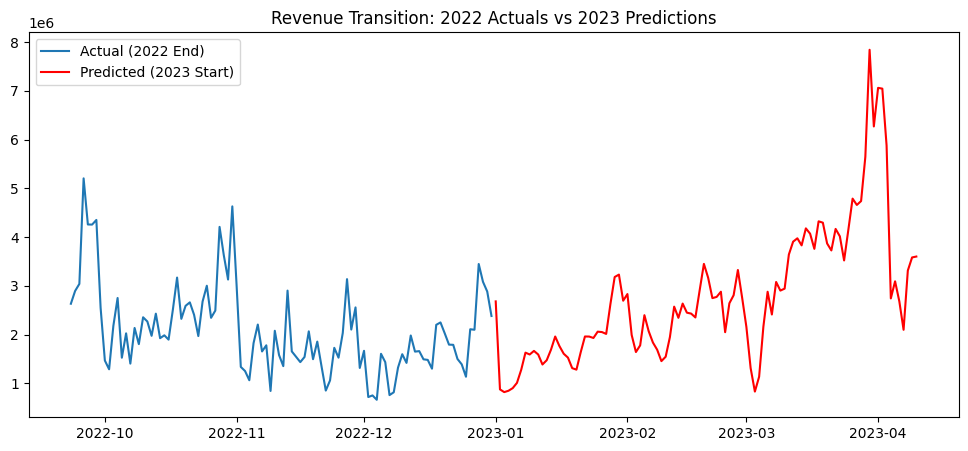

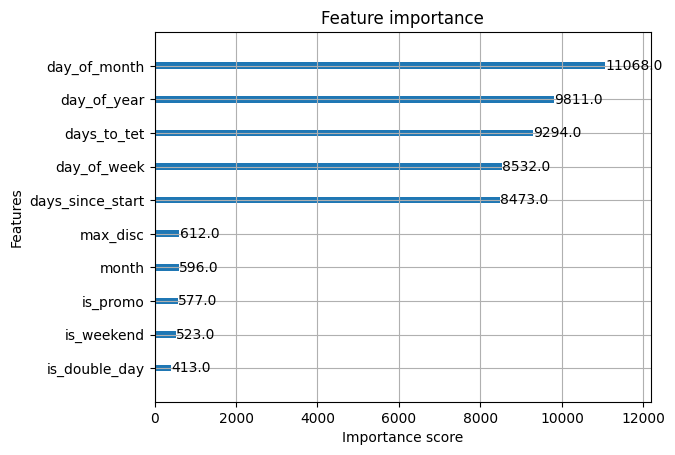

In [7]:
# Compare Training Tail with Prediction Head
plt.figure(figsize=(12, 5))
plt.plot(
    train_df["Date"].tail(100),
    train_df["Revenue"].tail(100), 
    label="Actual (2022 End)"
)
plt.plot(
    test_df["Date"].head(100),
    test_df["Revenue"].head(100),
    label="Predicted (2023 Start)",
    color="red",
)
plt.title("Revenue Transition: 2022 Actuals vs 2023 Predictions")
plt.legend()
plt.show()

# Feature Importance
plot_importance(model_rev, max_num_features=10)
plt.show()

## Export Submission


In [8]:
submission = test_df[["Date", "Revenue", "COGS"]].copy()
submission["Date"] = submission["Date"].dt.strftime("%Y-%m-%d")
submission.to_csv("submission.csv", index=False)
print("Saved 'submission.csv'!")

Saved 'submission.csv'!


In [9]:
pd.read_csv("/kaggle/working/submission.csv")

,Date,Revenue,COGS
0,2023-01-01,2682142.50,2278142.00
1,2023-01-02,877410.60,745509.75
2,2023-01-03,821609.25,800821.25
3,2023-01-04,849249.25,797348.50
4,2023-01-05,903202.50,845747.10
...,...,...,...
543,2024-06-27,4490403.50,4023924.20
544,2024-06-28,4349203.00,4284846.50
545,2024-06-29,4524634.00,4056026.00
546,2024-06-30,5160365.50,4172898.00
